In [376]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [344]:
df_fi = pd.read_parquet("dane/interim/fact_inka_records_2023_2026.parquet")

In [ ]:


polish_map = str.maketrans({
    "ą": "a", "ć": "c", "ę": "e", "ł": "l",
    "ń": "n", "ó": "o", "ś": "s", "ź": "z", "ż": "z",
    "Ą": "A", "Ć": "C", "Ę": "E", "Ł": "L",
    "Ń": "N", "Ó": "O", "Ś": "S", "Ź": "Z", "Ż": "Z"
})

def CleanName(text: str):
    # if pd.isna(text):
    #     return ""
    text = str(text)
    text = text.translate(polish_map)         # zamiana PL → ASCII 1:1
    text = text.lower()
    text = re.sub(r"[^a-z0-9]+", " ", text)   # zamiana reszty na spację
    text = re.sub(r"\s+", " ", text).strip()  # redukcja wielokrotnych spacji
    return text

def process_df(df):
    df = df.copy()

    # dodanie kolumny NazwaTowCleanName
    df["NazwaTowCleanName"] = df["NazwaTow"].astype(str).apply(CleanName)

    return df

def process_df_asid(df):
    df = df.copy()

    # dodanie kolumny NazwaAsortCleanName
    df["NazwaAsortCleanName"] = df["NazwaAsort"].astype(str).apply(CleanName)

    return df

In [346]:
df_fi = process_df(df_fi.copy())

In [347]:
df_fi = process_df_asid(df_fi.copy())

In [349]:
# ============================================================
# HARD WYKLUCZENIA
# Kategorie które nie pochodzą z magazynu centralnego SPAR
# lub nie są towarami fizycznymi
# ============================================================

# Prasa i gazety (osobny system zamawiania - kolportaż)
asid_prasa = {132, 133, 273}

# Kiosk - bilety, zapalniczki, leki, baterie (nie z magazynu)
asid_kiosk = {245, 277, 278, 279, 283, 284, 285, 288, 290, 293, 275}

# Doładowania telefoniczne i startery (usługi, nie towary)
asid_doladowania = {47, 48, 255, 290, 330, 331, 332, 334, 335, 337, 338}

# Opakowania i techniczne (nie towary handlowe)
asid_techniczne = {
    256,  # OPAKOWANIA ZWROTNE
    352,  # reklamówki
    247,  # OPAKOWANIA /przemysłowe
    254,  # xx KOSZTY / RABATY
    244,  # Domyślny DO WERYFIKACJI
    354,  # xinne
}

# Łączna lista wykluczeń
lista_hard_wykluczen = (
    asid_prasa |
    asid_kiosk |
    asid_doladowania |
    asid_techniczne
)

print(f"Łącznie do twardego wykluczenia: {len(lista_hard_wykluczen)} AsId")

df_fi_hard = df_fi.copy()

# Filtrowanie AsId
df_fi_hard = df_fi_hard[~df_fi_hard['AsId'].isin(lista_hard_wykluczen)]

# Filtrowanie dokumentów bez NrDok
df_fi_hard = df_fi_hard[df_fi_hard['NrDok'].notna()]

print(f"Przed: {len(df_fi):,} rekordów")
print(f"Po:    {len(df_fi_hard):,} rekordów")
print(f"Usunięto: {len(df_fi) - len(df_fi_hard):,} rekordów")

Łącznie do twardego wykluczenia: 30 AsId
Przed: 4,260,543 rekordów
Po:    4,106,901 rekordów
Usunięto: 153,642 rekordów


## Jak wykluczyc produkty( TowId) które nie są sprzedawane od jakiegoś czasu

potrzeba policzyć datę ostatniej sprzedaży per TowId i porównać ją z datą odniesienia (koniec danych albo dzisiejsza data). Produkty, które "milczą" dłużej niż przyjęty próg  oznaczasz jako dead stock / do wykluczenia.


In [350]:
# ============================================================
# Ostatnia sprzedaż per TowId + wykluczenie "martwych" produktów
# ============================================================

# 1. Tylko rekordy sprzedaży
df_sprzedaz = df_fi_hard[df_fi_hard['TypRuchu'] == 'sprzedaz'].copy()

# 2. Data odniesienia — koniec zakresu danych (albo pd.Timestamp.now(), jeśli wolisz "dziś")
data_odniesienia = df_fi_hard['Data'].max()
print(f"Data odniesienia: {data_odniesienia}")

# 3. Ostatnia sprzedaż per TowId
ostatnia_sprzedaz = (
    df_sprzedaz
    .groupby('TowId')['Data']
    .max()
    .reset_index()
    .rename(columns={'Data': 'OstatniaSprzedaz'})
)

ostatnia_sprzedaz['DniOdOstatniejSprzedazy'] = (
    data_odniesienia - ostatnia_sprzedaz['OstatniaSprzedaz']
).dt.days


Data odniesienia: 2026-01-31 00:00:00


In [351]:
#  Progi rotacji wyliczone z percentyli rzeczywistego rozkładu

percentyle = ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].quantile(
    [0.10, 0.25, 0.50, 0.75, 0.80, 0.90, 0.95, 0.99]
)
print(percentyle)

0.10       0.0
0.25       3.0
0.50     101.0
0.75     543.0
0.80     655.0
0.90     879.0
0.95    1013.0
0.99    1102.0
Name: DniOdOstatniejSprzedazy, dtype: float64


In [ ]:
# 4. Próg "martwego" produktu obliczone poniżej
prog_dni = 550 # patrz komórka wyżej

towid_martwe = ostatnia_sprzedaz[
    ostatnia_sprzedaz['DniOdOstatniejSprzedazy'] > prog_dni
]['TowId']

print(f"TowId z ostatnią sprzedażą >{prog_dni} dni temu: {len(towid_martwe)} pozycji")

# 5. TowId, które W OGÓLE nie mają sprzedaży w danych (np. tylko przyjęcia, zwroty itp.)
wszystkie_towid = df_fi_hard['TowId'].unique()
towid_bez_sprzedazy = set(wszystkie_towid) - set(ostatnia_sprzedaz['TowId'])
print(f"TowId bez żadnej sprzedaży w okresie: {len(towid_bez_sprzedazy)} pozycji")

# 6. Finalna lista do wykluczenia
towid_do_wykluczenia = set(towid_martwe) | towid_bez_sprzedazy

df_fi_soft = df_fi_hard[~df_fi_hard['TowId'].isin(towid_do_wykluczenia)].copy()

print(f"Przed: {len(df_fi_hard):,} rekordów, {df_fi_hard['TowId'].nunique():,} TowId pozycji")
print(f"Po:    {len(df_fi_soft):,} rekordów, {df_fi_soft['TowId'].nunique():,} TowId pozycji")
print(f"Wykluczono: {len(towid_do_wykluczenia):,} TowId pozycji")

TowId z ostatnią sprzedażą >550 dni temu: 3097 pozycji
TowId bez żadnej sprzedaży w okresie: 7211 pozycji
Przed: 4,106,901 rekordów, 19,692 TowId pozycji
Po:    3,877,845 rekordów, 9,384 TowId pozycji
Wykluczono: 10,308 TowId pozycji


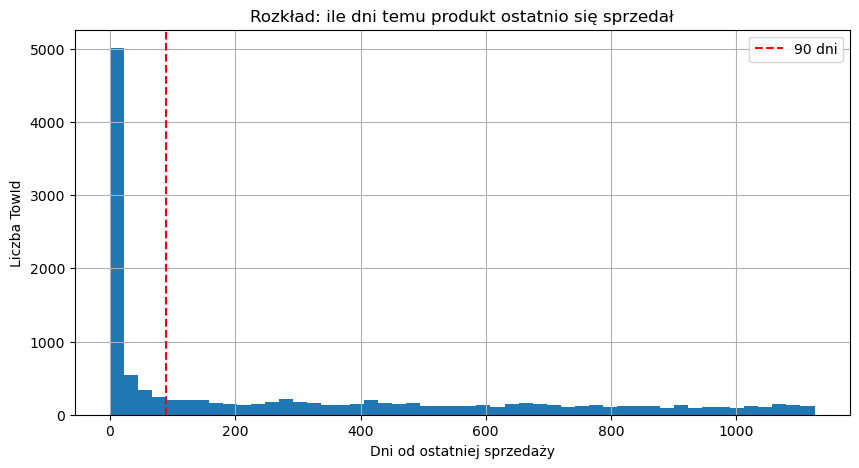

count    12481.000000
mean       291.740966
std        349.584776
min          0.000000
25%          3.000000
50%        101.000000
75%        543.000000
max       1125.000000
Name: DniOdOstatniejSprzedazy, dtype: float64

Percentyle:
0.50     101.0
0.75     543.0
0.90     879.0
0.95    1013.0
0.99    1102.0
Name: DniOdOstatniejSprzedazy, dtype: float64


In [353]:



plt.figure(figsize=(10, 5))
ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].hist(bins=50)
plt.axvline(90, color='red', linestyle='--', label='90 dni')
plt.xlabel('Dni od ostatniej sprzedaży')
plt.ylabel('Liczba TowId')
plt.title('Rozkład: ile dni temu produkt ostatnio się sprzedał')
plt.legend()
plt.show()

print(ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].describe())
print("\nPercentyle:")
print(ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

In [354]:
# Progi oparte na rzeczywistym kształcie rozkładu (median vs. duży skok do 75 percentyla)
prog_aktywny = 100     # ~mediana, tu kończy się gęsty szczyt
prog_zagrozony = 550   # ~75 percentyl, tu zaczyna się długi "ogon"
# powyżej 550 dni = martwy

def kategoria_rotacji(dni):
    if dni <= prog_aktywny:
        return 'aktywny'
    elif dni <= prog_zagrozony:
        return 'zagrozony'
    else:
        return 'martwy'

ostatnia_sprzedaz['KategoriaRotacji'] = ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].apply(kategoria_rotacji)
print(ostatnia_sprzedaz['KategoriaRotacji'].value_counts())

KategoriaRotacji
aktywny      6234
zagrozony    3150
martwy       3097
Name: count, dtype: int64


## Czy warto wykluczac martwe

In [355]:
# Ile TowId w każdej kategorii i jaki mają udział w wartości sprzedaży
towid_kategoria = ostatnia_sprzedaz[['TowId', 'KategoriaRotacji']]

df_z_kategoria = df_sprzedaz.merge(towid_kategoria, on='TowId', how='left')

podsumowanie = df_z_kategoria.groupby('KategoriaRotacji').agg(
    LiczbaTowId=('TowId', 'nunique'),
    WartoscSprzedazy=('Wartosc', 'sum'),
    LiczbaTransakcji=('TowId', 'count')
).reset_index()

podsumowanie['UdzialProcentowy'] = (
    podsumowanie['WartoscSprzedazy'] / podsumowanie['WartoscSprzedazy'].sum() * 100
).round(2)

print(podsumowanie)

  KategoriaRotacji  LiczbaTowId  WartoscSprzedazy  LiczbaTransakcji  \
0          aktywny         6234      1.568790e+07           2952692   
1           martwy         3097      6.988666e+05            128113   
2        zagrozony         3150      1.706317e+06            293170   

   UdzialProcentowy  
0             86.71  
1              3.86  
2              9.43  


### czy martwe produkty kiedys sie dobrze sprzedawały

In [356]:
# Ile ŚREDNIO transakcji/wartości miał pojedynczy "martwy" TowId?
martwe_stats = df_z_kategoria[df_z_kategoria['KategoriaRotacji'] == 'martwy'].groupby('TowId').agg(
    Wartosc=('Wartosc', 'sum'),
    Transakcje=('TowId', 'count')
).reset_index()

print(martwe_stats.describe())
print("\nTop 10 martwych wg wartości historycznej:")
print(martwe_stats.sort_values('Wartosc', ascending=False).head(10))

              TowId      Wartosc   Transakcje
count   3097.000000  3097.000000  3097.000000
mean   51200.617695   225.659231    41.366807
std    20406.234440   457.025603    81.791807
min       74.000000     0.804900     1.000000
25%    50081.000000    26.590400     4.000000
50%    54343.000000    90.860000    12.000000
75%    66260.000000   242.130000    42.000000
max    78789.000000  8529.456400  1016.000000

Top 10 martwych wg wartości historycznej:
      TowId    Wartosc  Transakcje
831   50771  8529.4564         913
897   51267  7045.5520         525
1142  52563  6837.5445         401
1465  54095  5084.2007         716
636   38284  4882.6415         261
721   49431  4261.3026         341
763   49968  4007.9900          66
1228  53141  3962.5672         690
1517  54237  3951.4093         567
1328  53647  3938.8873        1016


## Trzeba sprawdzić czy martwe produkty zostały wycofane ze sprzedazy czy tez jest to problem sezonowości

In [357]:
top10_towid = martwe_stats.sort_values('Wartosc', ascending=False).head(10)['TowId']

wzorzec_top10 = df_sprzedaz[df_sprzedaz['TowId'].isin(top10_towid)].copy()
wzorzec_top10['RokMiesiac'] = wzorzec_top10['Data'].dt.to_period('M')

sprzedaz_w_czasie = wzorzec_top10.groupby(['TowId', 'RokMiesiac'])['Wartosc'].sum().unstack(fill_value=0)
print(sprzedaz_w_czasie)

# Dołączmy nazwy dla kontekstu
nazwy = df_fi_hard[['TowId', 'NazwaTow']].drop_duplicates()
print(nazwy[nazwy['TowId'].isin(top10_towid)])

RokMiesiac   2023-01    2023-02    2023-03    2023-04    2023-05    2023-06  \
TowId                                                                         
38284       316.8620   243.7400   601.1457   390.6501   535.2437   377.0000   
49431       212.1948   188.6176   533.4392   548.4150   548.4150   645.9110   
49968        20.0000   290.0000   420.0000   650.0000   330.0000    70.0000   
50771       672.2418  1047.3792  1301.7038  1794.6295  1180.3137  1580.6545   
51267       814.0660   560.6020  1438.0660   962.7730   995.2450   898.5460   
52563       284.3500   352.5940   739.3096   412.1867   518.6987   683.7393   
53141       144.2232   174.2697   198.3069   192.2976   234.3627   180.2789   
53647         0.0000     0.0000    73.0487   103.2116   163.3986   136.0894   
54095       357.2747   295.5839   400.3393   269.1937   282.9985   393.4371   
54237       168.8935   186.3648   234.6817   310.6083   276.0960   255.3889   

RokMiesiac   2023-07   2023-08   2023-09   2023-10 

In [358]:
# Zamiast pivotu z obciętym wyświetlaniem, sprawdźmy wprost ostatnią sprzedaż per TowId
top10_towid = martwe_stats.sort_values('Wartosc', ascending=False).head(10)['TowId']

ostatnia_sprzedaz_top10 = df_sprzedaz[df_sprzedaz['TowId'].isin(top10_towid)].groupby('TowId').agg(
    PierwszaSprzedaz=('Data', 'min'),
    OstatniaSprzedaz=('Data', 'max'),
    LiczbaMiesiecyZeSprzedaza=('Data', lambda x: x.dt.to_period('M').nunique())
).reset_index()

print(ostatnia_sprzedaz_top10.sort_values('OstatniaSprzedaz'))

   TowId PierwszaSprzedaz OstatniaSprzedaz  LiczbaMiesiecyZeSprzedaza
3  50771       2023-01-02       2023-07-29                          7
4  51267       2023-01-02       2023-08-12                          8
0  38284       2023-01-07       2023-10-11                         10
1  49431       2023-01-03       2023-11-18                         11
7  53647       2023-03-21       2024-02-16                         12
5  52563       2023-01-04       2024-03-14                         15
8  54095       2023-01-02       2024-04-30                         16
9  54237       2023-01-02       2024-06-01                         18
2  49968       2023-01-13       2024-06-12                         16
6  53141       2023-01-04       2024-07-20                         19


In [359]:
# A teraz sprawdzam jak zachowują się wszystkie martwe 
# Dla WSZYSTKICH martwych TowId 
martwe_towid = ostatnia_sprzedaz[ostatnia_sprzedaz['KategoriaRotacji'] == 'martwy']['TowId']

df_sprzedaz_martwe = df_sprzedaz[df_sprzedaz['TowId'].isin(martwe_towid)]

profil_martwych = df_sprzedaz_martwe.groupby('TowId').agg(
    PierwszaSprzedaz=('Data', 'min'),
    OstatniaSprzedaz=('Data', 'max'),
    LiczbaMiesiecyZeSprzedaza=('Data', lambda x: x.dt.to_period('M').nunique()),
    LiczbaTransakcji=('Data', 'count'),
    Wartosc=('Wartosc', 'sum')
).reset_index()

# Długość "życia" produktu w dniach
profil_martwych['DlugoscZyciaDni'] = (
    profil_martwych['OstatniaSprzedaz'] - profil_martwych['PierwszaSprzedaz']
).dt.days

print(profil_martwych[['LiczbaMiesiecyZeSprzedaza', 'LiczbaTransakcji', 'DlugoscZyciaDni']].describe())

       LiczbaMiesiecyZeSprzedaza  LiczbaTransakcji  DlugoscZyciaDni
count                3097.000000       3097.000000      3097.000000
mean                    4.849532         41.366807       153.126251
std                     4.243778         81.791807       155.419980
min                     1.000000          1.000000         0.000000
25%                     2.000000          4.000000        18.000000
50%                     3.000000         12.000000       100.000000
75%                     7.000000         42.000000       256.000000
max                    19.000000       1016.000000       571.000000


In [360]:
# Miesiące ostatniej sprzedaży martwych produktów
profil_martwych['Ilość'] = profil_martwych['OstatniaSprzedaz'].dt.to_period('M')
rozklad_konca = profil_martwych['Ilość'].value_counts().sort_index()
print(f'Miesiąc {rozklad_konca}')

Miesiąc Ilość
2023-01    159
2023-02    179
2023-03    157
2023-04    166
2023-05    131
2023-06    136
2023-07    148
2023-08    155
2023-09    151
2023-10    168
2023-11    134
2023-12    184
2024-01    159
2024-02    163
2024-03    210
2024-04    204
2024-05    167
2024-06    169
2024-07    157
Freq: M, Name: count, dtype: int64


# Sezonowość

In [361]:
# Wykrycie czy TwoId są sezonowe, czy też nie.
# Dodajemy miesiąc do rekordów sprzedaży
df_sprzedaz['Miesiac'] = df_sprzedaz['Data'].dt.month
df_sprzedaz['Rok'] = df_sprzedaz['Data'].dt.year

# Sprawdzamy w ilu różnych miesiącach i latach dany TowId się sprzedawał
sezonowosc = df_sprzedaz.groupby('TowId').agg(
    LiczbaAktywnychMiesiecy=('Miesiac', 'nunique'),   # ile z 12 miesięcy ma sprzedaż
    LiczbaAktywnychLat=('Rok', 'nunique'),
    PierwszaSprzedaz=('Data', 'min'),
    OstatniaSprzedaz=('Data', 'max')
).reset_index()

# Produkt "całoroczny" sprzedaje się w ~10-12 miesiącach
# Produkt sezonowy sprzedaje się tylko w 1-4 miesiącach, ale powtarzalnie w tych samych
print(sezonowosc['LiczbaAktywnychMiesiecy'].describe())

count    12481.000000
mean         7.923884
std          4.192882
min          1.000000
25%          4.000000
50%          9.000000
75%         12.000000
max         12.000000
Name: LiczbaAktywnychMiesiecy, dtype: float64


In [362]:
#  koncentracji sprzedaży w top 3 miesiącach,
# Suma wartości sprzedaży per TowId per miesiąc (agregacja po wszystkich latach)
sprzedaz_per_miesiac = df_sprzedaz.groupby(['TowId', 'Miesiac'])['Wartosc'].sum().reset_index()

def koncentracja_top3(grupa):
    total = grupa['Wartosc'].sum()
    top3 = grupa.nlargest(3, 'Wartosc')['Wartosc'].sum()
    return top3 / total if total > 0 else 0

koncentracja = (
    sprzedaz_per_miesiac
    .groupby('TowId')
    .apply(koncentracja_top3, include_groups=False)
    .reset_index()
)
koncentracja.columns = ['TowId', 'KoncentracjaTop3Miesiace']

print(koncentracja['KoncentracjaTop3Miesiace'].describe())

count    12481.000000
mean         0.623502
std          0.262865
min          0.265542
25%          0.374954
50%          0.553294
75%          0.918919
max          1.000000
Name: KoncentracjaTop3Miesiace, dtype: float64


### Wniosek : Interpretacja:

Teoretyczne minimum dla równomiernego rozkładu sprzedaży na 12 miesięcy to 3/12 = 0.25 (top 3 miesiące = 25% wartości, jeśli wszystkie miesiące są równe). Twój min = 0.2655 jest bardzo blisko tej wartości — czyli są produkty praktycznie idealnie równomierne.
Mediana = 0.553 — to znaczy, że typowy produkt ma aż 55% swojej rocznej wartości skoncentrowane w zaledwie 3 z 12 miesięcy. To znacznie więcej niż losowe 25%.
75 percentyl = 0.92 — czyli jedna czwarta wszystkich TowId ma 92%+ wartości w 3 miesiącach — to bardzo silna koncentracja, praktycznie sezonowość podręcznikowa.

Wniosek, który zmienia wcześniejszą interpretację: mimo że mediana "aktywnych miesięcy" wynosiła 9 (sugerując sprzedaż "cały rok"), okazuje się, że większość produktów ma wyraźne szczyty sezonowe, nawet jeśli formalnie sprzedają się przez większość roku. To ma sens biznesowo — sklep spożywczy/detaliczny naturalnie ma wzorce: więcej przed świętami, w wakacje, itd., nawet dla produktów "całorocznych".

To jest ważne, bo potwierdza zasadność Twojej wcześniejszej obawy o sezonowość — bez tego uwzględnienia, część "martwych" (ostatnia sprzedaż dawno temu) może być błędnie zakwalifikowana, jeśli akurat mijamy się z ich sezonem szczytowym.

In [363]:
sezonowosc_pelna = sezonowosc.merge(koncentracja, on='TowId', how='left')

# Kryterium: silna koncentracja (>70%) I potwierdzona przez min. 2 lata historii
sezonowosc_pelna['PrawdopodobnieSezonowy'] = (
    (sezonowosc_pelna['KoncentracjaTop3Miesiace'] > 0.70) &
    (sezonowosc_pelna['LiczbaAktywnychLat'] >= 2)
)

print(sezonowosc_pelna['PrawdopodobnieSezonowy'].value_counts())
print(f"\n% sezonowych: {sezonowosc_pelna['PrawdopodobnieSezonowy'].mean()*100:.1f}%")

# Ile z martwych TowId to potencjalnie sezonowe?
sezonowosc_pelna_martwe = sezonowosc_pelna[sezonowosc_pelna['TowId'].isin(martwe_towid)]
print(f"\nWśród martwych ({len(martwe_towid)}): {sezonowosc_pelna_martwe['PrawdopodobnieSezonowy'].sum()} to prawdopodobnie sezonowe")

PrawdopodobnieSezonowy
False    10807
True      1674
Name: count, dtype: int64

% sezonowych: 13.4%

Wśród martwych (3097): 326 to prawdopodobnie sezonowe


Podsumowanie:

Ogółem 13.4% całego katalogu (1674 z 12481 TowId) wykazuje wzorzec silnej sezonowości (>70% wartości w 3 miesiącach, potwierdzone przez ≥2 lata historii).
Wśród martwych: 326 z 3097 (czyli 10.5%) to prawdopodobnie produkty sezonowe, błędnie zakwalifikowane jako martwe — 

Co to znaczy praktycznie: Twoja intuicja z wcześniejszej rozmowy była słuszna — sezonowość rzeczywiście zniekształca kategorię martwy, ale w umiarkowanej skali (10.5% tej grupy, nie większość). Reszta — 2771 z 3097 (89.5%) — to nadal prawdopodobnie faktycznie martwe produkty (potwierdzone też wcześniej medianą: 3 miesiące aktywności, 12 transakcji, brak długiej historii — profil niepasujący do sezonowości).

In [364]:
# Finalna, poprawiona kategoryzacja — z uwzględnieniem sezonowości
rotacja_finalna = ostatnia_sprzedaz.merge(
    sezonowosc_pelna[['TowId', 'PrawdopodobnieSezonowy']], 
    on='TowId', how='left'
)

def kategoria_rotacji_finalna(row):
    dni = row['DniOdOstatniejSprzedazy']
    sezonowy = row['PrawdopodobnieSezonowy']
    
    if dni <= 100:
        return 'aktywny'
    if sezonowy:
        return 'sezonowy_poza_sezonem'
    if dni <= 550:
        return 'zagrozony'
    return 'martwy'

rotacja_finalna['KategoriaRotacji'] = rotacja_finalna.apply(kategoria_rotacji_finalna, axis=1)
print(rotacja_finalna['KategoriaRotacji'].value_counts())

KategoriaRotacji
aktywny                  6234
martwy                   2771
zagrozony                2475
sezonowy_poza_sezonem    1001
Name: count, dtype: int64


### Oflagowanie produktów r 'aktywny  'wolno_rotujacy' 'zagrozony' 'martwy'
# Po powyzszej analizie stosuje oflagowanie kazdego produktu 

In [365]:
# ============================================================
# SOFT FILTER — Kryterium 1: Rotacja / martwe produkty
# BEZ USUWANIA — tylko flagowanie, decyzja o filtrze przy analizie
# ============================================================

# 1. Rekordy sprzedaży z df_fi_hard
df_sprzedaz = df_fi_hard[df_fi_hard['TypRuchu'] == 'sprzedaz'].copy()

# 2. Data odniesienia
data_odniesienia = df_fi_hard['Data'].max()

# 3. Ostatnia sprzedaż per TowId
ostatnia_sprzedaz = (
    df_sprzedaz
    .groupby('TowId')['Data']
    .max()
    .reset_index()
    .rename(columns={'Data': 'OstatniaSprzedaz'})
)
ostatnia_sprzedaz['DniOdOstatniejSprzedazy'] = (
    data_odniesienia - ostatnia_sprzedaz['OstatniaSprzedaz']
).dt.days


ostatnia_sprzedaz['KategoriaRotacji'] = ostatnia_sprzedaz['DniOdOstatniejSprzedazy'].apply(kategoria_rotacji)

# 4. TowId bez żadnej sprzedaży w ogóle
wszystkie_towid = df_fi_hard['TowId'].unique()
towid_bez_sprzedazy = set(wszystkie_towid) - set(ostatnia_sprzedaz['TowId'])

brak_sprzedazy_df = pd.DataFrame({
    'TowId': list(towid_bez_sprzedazy),
    'OstatniaSprzedaz': pd.NaT,
    'DniOdOstatniejSprzedazy': np.nan,
    'KategoriaRotacji': 'martwy'
})

rotacja_towid = pd.concat([ostatnia_sprzedaz, brak_sprzedazy_df], ignore_index=True)

print("Rozkład kategorii rotacji:")
print(rotacja_towid['KategoriaRotacji'].value_counts())

# 6. Dołączenie flag do CAŁEGO zbioru — bez usuwania żadnego rekordu
df_fi_soft = df_fi_hard.merge(
    rotacja_towid[['TowId', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy', 'KategoriaRotacji']],
    on='TowId',
    how='left'
)

# 7. Dodatkowe, gotowe flagi boolowskie — do szybkiego filtrowania w analizach
df_fi_soft['JestMartwy'] = df_fi_soft['KategoriaRotacji'] == 'martwy'
df_fi_soft['JestAktywny'] = df_fi_soft['KategoriaRotacji'] == 'aktywny'
df_fi_soft['WymagaUwagi'] = df_fi_soft['KategoriaRotacji'].isin(['zagrozony', 'wolno_rotujacy'])

print(f"\nRekordów łącznie: {len(df_fi_soft):,} (bez zmian względem df_fi_hard: {len(df_fi_hard):,})")
print(f"TowId łącznie: {df_fi_soft['TowId'].nunique():,}")
# Zapis oflagowanych produktów do pliku Parquet z kompresją Zstandard (zstd)
df_fi_soft.to_parquet(
    "dane/interim/fact_inka_soft_flagged_rotacja.parquet",
    compression='zstd',
    index=False
)
print(f"Zapisano: {df_fi_soft.shape}")

Rozkład kategorii rotacji:
KategoriaRotacji
martwy       10308
aktywny       6234
zagrozony     3150
Name: count, dtype: int64

Rekordów łącznie: 4,106,901 (bez zmian względem df_fi_hard: 4,106,901)
TowId łącznie: 19,692
Zapisano: (4106901, 38)


### Uwaga tu dostalismy 10308 martwych a wczesniej było 3097 . Skąd ta rozbieność
 Co to za produkty - jakie mają dokumenty, jeśli nie sprzedaż?


In [366]:
# Co to za produkty - jakie mają dokumenty, jeśli nie sprzedaż?
sprawdz = df_fi_hard[df_fi_hard['TowId'].isin(towid_bez_sprzedazy)]
print(sprawdz['TypRuchu'].value_counts())
print(sprawdz['Dokument'].value_counts())

# Przykładowe nazwy
print(sprawdz[['TowId', 'NazwaTow', 'Dokument']].drop_duplicates().head(20))

TypRuchu
remanent        20708
bo              13765
neutralny       10265
przecena         4326
przesuniecie      156
przyjecie         153
strata            127
rozchod            41
rozbieznosc        28
Name: count, dtype: int64
Dokument
REM               20708
BO                13765
ZM_ST_VAT          8120
PRZEC              4314
PLAN_ZM_ST_VAT     2030
PZ                  153
ST                  127
PRZES               120
ZAM                 110
RW                   41
PRZES_GR             36
ROZB                 28
ZAMR_PRZEC           12
DF                    5
Name: count, dtype: int64
      TowId                                           NazwaTow Dokument
201   52016                  PRZEC SAŁATKA JARZYNOWA 200G SPAR       ST
205   55315         PRZEC ŚLEDŹ KOLOROWY PIEPRZ 900G SUPERFISH       ST
214   51435                  GALARETKA LEMONIADA ANANAS WINIAR       ST
215   51436                 GALARETKA WODA KOKOSOWA 40G WINIAR       ST
219   24138                     ORZE

Wniosek: to nie są "martwe produkty" w sensie biznesowym, tylko produkty, których jedyny ślad w danych to operacje magazynowo-księgowe. Przykłady z tabeli (MASA KRÓWKOWA...ZAM, PAPIEROSY WINSTON...ZAM, KROPLE MENTHOL...ZAM) to zwykłe nazwy towarów — więc to nie jest kwestia "dziwnych" pozycji technicznych (te już wyleciały w hard-wykluczeniach), tylko normalnych produktów, które akurat w Twoim oknie danych 2023-2026 nigdy nie miały zarejestrowanej transakcji sprzedaży TypRuchu == 'sprzedaz', mimo że są np. na stanie (remanent, BO) albo były przecenione.

In [367]:
def kategoria_rotacji_v3(dni):
    if pd.isna(dni['DniOdOstatniejSprzedazy']):
        return 'nigdy_nie_sprzedany'   # osobna etykieta, nie "martwy"
    dni = dni['DniOdOstatniejSprzedazy']
    if dni <= 100:
        return 'aktywny'
    elif dni <= 550:
        return 'zagrozony'
    else:
        return 'martwy'

In [368]:
# ============================================================
# SOFT FILTER — Kryterium 1: Rotacja / martwe produkty
# BEZ USUWANIA — tylko flagowanie, decyzja o filtrze przy analizie
# Wersja finalna: z rozróżnieniem "martwy" vs "nigdy_nie_sprzedany" + sezonowość
# ============================================================

# 1. Rekordy sprzedaży z df_fi_hard
df_sprzedaz = df_fi_hard[df_fi_hard['TypRuchu'] == 'sprzedaz'].copy()

# 2. Data odniesienia
data_odniesienia = df_fi_hard['Data'].max()

# 3. Ostatnia sprzedaż per TowId (tylko dla TowId z choć jedną sprzedażą)
ostatnia_sprzedaz = (
    df_sprzedaz
    .groupby('TowId')['Data']
    .max()
    .reset_index()
    .rename(columns={'Data': 'OstatniaSprzedaz'})
)
ostatnia_sprzedaz['DniOdOstatniejSprzedazy'] = (
    data_odniesienia - ostatnia_sprzedaz['OstatniaSprzedaz']
).dt.days

# 4. Sezonowość — do odróżnienia "martwy" od "sezonowy poza sezonem"
df_sprzedaz['Miesiac'] = df_sprzedaz['Data'].dt.month
df_sprzedaz['Rok'] = df_sprzedaz['Data'].dt.year

sezonowosc = df_sprzedaz.groupby('TowId').agg(
    LiczbaAktywnychLat=('Rok', 'nunique'),
).reset_index()

sprzedaz_per_miesiac = df_sprzedaz.groupby(['TowId', 'Miesiac'])['Wartosc'].sum().reset_index()

def koncentracja_top3(grupa):
    total = grupa['Wartosc'].sum()
    top3 = grupa.nlargest(3, 'Wartosc')['Wartosc'].sum()
    return top3 / total if total > 0 else 0

koncentracja = (
    sprzedaz_per_miesiac
    .groupby('TowId')
    .apply(koncentracja_top3, include_groups=False)
    .reset_index()
)
koncentracja.columns = ['TowId', 'KoncentracjaTop3Miesiace']

sezonowosc = sezonowosc.merge(koncentracja, on='TowId', how='left')
sezonowosc['PrawdopodobnieSezonowy'] = (
    (sezonowosc['KoncentracjaTop3Miesiace'] > 0.70) &
    (sezonowosc['LiczbaAktywnychLat'] >= 2)
)

ostatnia_sprzedaz = ostatnia_sprzedaz.merge(
    sezonowosc[['TowId', 'PrawdopodobnieSezonowy']], on='TowId', how='left'
)

# 5. Kategoryzacja — TYLKO dla TowId z historią sprzedaży
def kategoria_rotacji(row):
    dni = row['DniOdOstatniejSprzedazy']
    sezonowy = row['PrawdopodobnieSezonowy']
    if dni <= 100:
        return 'aktywny'
    if sezonowy:
        return 'sezonowy_poza_sezonem'
    if dni <= 550:
        return 'zagrozony'
    return 'martwy'

ostatnia_sprzedaz['KategoriaRotacji'] = ostatnia_sprzedaz.apply(kategoria_rotacji, axis=1)

# 6. TowId BEZ żadnej sprzedaży w ogóle — osobna kategoria, NIE "martwy"
wszystkie_towid = df_fi_hard['TowId'].unique()
towid_bez_sprzedazy = set(wszystkie_towid) - set(ostatnia_sprzedaz['TowId'])

brak_sprzedazy_df = pd.DataFrame({
    'TowId': list(towid_bez_sprzedazy),
    'OstatniaSprzedaz': pd.NaT,
    'DniOdOstatniejSprzedazy': np.nan,
    'PrawdopodobnieSezonowy': False,
    'KategoriaRotacji': 'nigdy_nie_sprzedany'   # ← osobna etykieta
})

rotacja_towid = pd.concat([ostatnia_sprzedaz, brak_sprzedazy_df], ignore_index=True)

print("Rozkład kategorii rotacji:")
print(rotacja_towid['KategoriaRotacji'].value_counts())

# 7. Dołączenie flag do CAŁEGO zbioru — bez usuwania żadnego rekordu
df_fi_soft = df_fi_hard.merge(
    rotacja_towid[['TowId', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy',
                    'PrawdopodobnieSezonowy', 'KategoriaRotacji']],
    on='TowId',
    how='left'
)

# 8. Gotowe flagi boolowskie — do szybkiego filtrowania w analizach
df_fi_soft['JestAktywny'] = df_fi_soft['KategoriaRotacji'] == 'aktywny'
df_fi_soft['JestSezonowyPozaSezonem'] = df_fi_soft['KategoriaRotacji'] == 'sezonowy_poza_sezonem'
df_fi_soft['WymagaUwagi'] = df_fi_soft['KategoriaRotacji'] == 'zagrozony'
df_fi_soft['JestMartwy'] = df_fi_soft['KategoriaRotacji'] == 'martwy'
df_fi_soft['NigdyNieSprzedany'] = df_fi_soft['KategoriaRotacji'] == 'nigdy_nie_sprzedany'

# Zbiorcza flaga — do prognozy sprzedaży (wyklucza obie "martwe" grupy, zostawia sezonowe)
df_fi_soft['WykluczZPrognozy'] = df_fi_soft['KategoriaRotacji'].isin(
    ['martwy', 'nigdy_nie_sprzedany']
)

print(f"\nRekordów łącznie: {len(df_fi_soft):,} (bez zmian względem df_fi_hard: {len(df_fi_hard):,})")
print(f"TowId łącznie: {df_fi_soft['TowId'].nunique():,}")

Rozkład kategorii rotacji:
KategoriaRotacji
nigdy_nie_sprzedany      7211
aktywny                  6234
martwy                   2771
zagrozony                2475
sezonowy_poza_sezonem    1001
Name: count, dtype: int64

Rekordów łącznie: 4,106,901 (bez zmian względem df_fi_hard: 4,106,901)
TowId łącznie: 19,692


In [371]:
# Czy jakikolwiek TowId ma więcej niż jedną kategorię rotacji?
sprawdzenie = df_fi_soft.groupby('TowId')['KategoriaRotacji'].nunique()
liczba_niespojnych = (sprawdzenie > 1).sum()

print(f"TowId z więcej niż 1 kategorią (powinno być 0): {liczba_niespojnych}")

if liczba_niespojnych == 0:
    print("✓ Wszystko spójne — merge zadziałał poprawnie.")
else:
    # jeśli jednak >0, pokaż przykłady do diagnozy
    problematyczne = sprawdzenie[sprawdzenie > 1].index
    print(df_fi_soft[df_fi_soft['TowId'].isin(problematyczne)][['TowId', 'KategoriaRotacji']].drop_duplicates())

TowId z więcej niż 1 kategorią (powinno być 0): 0
✓ Wszystko spójne — merge zadziałał poprawnie.


In [372]:
# Lista unikalnych martwych towarów
martwe_towary = (
    df_fi_soft[df_fi_soft['JestMartwy'] == True]
    [['TowId', 'NazwaTow', 'EAN', 'NazwaAsort', 'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy']]
    .drop_duplicates(subset='TowId')
    .sort_values('DniOdOstatniejSprzedazy', ascending=False)
)

print(f"Liczba martwych towarów: {len(martwe_towary)}")
print(martwe_towary)
martwe_towary.to_parquet("dane/interim/martwe_towary.parquet", index=False, compression='zstd')

Liczba martwych towarów: 2771
         TowId                                          NazwaTow  \
9        37370                NAPÓJ GAZ BUT SCHWEPPES 0,9L TONIC   
15       55178             PASTELLA ŚLIWKA Z BOCZKIEM 80G LISNER   
232      55361    PRZEC CHIPSY TORTILLA SÓL MORSKA BIO 125G SPAR   
29       55334                           MARG FLORA 225G UPFIELD   
1540     54065                      CHRUPKI MONSTER KETCHUP 100g   
...        ...                                               ...   
1853551  78441                          KAPUSTA KISZONA MŁODA KG   
1534686  77970                    DANIE RAMEN NOODLE 90G PAMAPOL   
2013152  78754  PRZEC JOGURT ACTIVIA B/L BRZOSK MARAK 270G DANON   
65596    54739                       ZNICZ Z83R 25CM 36H PROMIEŃ   
179190   65577                   MROŻ KOKARDKI W SOSIE 400G SPAR   

                  EAN                         NazwaAsort OstatniaSprzedaz  \
9        5.902860e+12                    NAPOJE GAZOWANE       2023-01-02   

### Towary wazone 

In [382]:
# ============================================================
# SOFT FILTER — Kryterium 2: Towary ważone (per TowId)
# Krok 1: % transakcji z ułamkową ilością per TowId
# ============================================================

wazone_check = df_fi_hard.groupby('TowId').agg(
    LiczbaTransakcji=('IloscPlus', 'count'),
    LiczbaUlamkowych=('IloscPlus', lambda x: (x % 1 != 0).sum()),
).reset_index()

wazone_check['PctUlamkowych'] = (
    wazone_check['LiczbaUlamkowych'] / wazone_check['LiczbaTransakcji'] * 100
)

print(wazone_check['PctUlamkowych'].describe())

count    19692.000000
mean         0.839439
std          8.473241
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.000000
Name: PctUlamkowych, dtype: float64


In [383]:


def czy_nazwa_sugeruje_wage(nazwa):
    nazwa = str(nazwa).upper().strip()
    
    # Wyklucz przypadki "liczba+KG" (stała gramatura opakowania, np. "0,5KG", "1,65KG")
    bez_gramatury = re.sub(r'\d+[\.,]?\d*\s*KG\b', '', nazwa)
    
    # Szukamy samodzielnego "KG" jako jednostki sprzedaży (bez liczby bezpośrednio przed nim)
    return bool(re.search(r'\bKG\b', bez_gramatury))

# Szybki test kontrolny
testy = [
    "Chleb mieszany 0.6 kg PRECELEK",         # False - gramatura
    "PROSZEK PERSIL UNIVERSAL 1,65KG HENKEL", # False - gramatura
    "MĄKA ZIEMNIACZANA 0,5KG",                # False - gramatura
    "SURÓWKA KG",                              # True - waga
    "BAKŁAŻAN KG POLSKA",                      # True - waga
    "SAŁATKA WIELKANOCNA KG GRZEŚKOWIAK",      # True - waga
]
for t in testy:
    print(f"{czy_nazwa_sugeruje_wage(t)}: {t}")

False: Chleb mieszany 0.6 kg PRECELEK
False: PROSZEK PERSIL UNIVERSAL 1,65KG HENKEL
False: MĄKA ZIEMNIACZANA 0,5KG
True: SURÓWKA KG
True: BAKŁAŻAN KG POLSKA
True: SAŁATKA WIELKANOCNA KG GRZEŚKOWIAK


In [384]:
nazwy_do_sprawdzenia = df_fi_hard[['TowId', 'NazwaTow']].drop_duplicates(subset='TowId')
nazwy_do_sprawdzenia['NazwaSugerujeWage'] = nazwy_do_sprawdzenia['NazwaTow'].apply(czy_nazwa_sugeruje_wage)

wazone_check_pelne = wazone_check.merge(nazwy_do_sprawdzenia, on='TowId', how='left')

wazone_check_pelne['JestWazony'] = (
    (wazone_check_pelne['PctUlamkowych'] >= 50) |
    (wazone_check_pelne['NazwaSugerujeWage'])
)

lista_wazonych_towid = set(wazone_check_pelne[wazone_check_pelne['JestWazony']]['TowId'])
print(f"Ważonych TowId (finalne kryterium): {len(lista_wazonych_towid)}")

dodane_przez_nazwe = wazone_check_pelne[
    (wazone_check_pelne['NazwaSugerujeWage']) & 
    (wazone_check_pelne['PctUlamkowych'] < 50)
]
print(f"\nDodatkowo złapane przez samodzielne 'KG' (bez liczby): {len(dodane_przez_nazwe)}")
print(dodane_przez_nazwe[['TowId', 'NazwaTow', 'PctUlamkowych']].sort_values('NazwaTow'))

Ważonych TowId (finalne kryterium): 238

Dodatkowo złapane przez samodzielne 'KG' (bez liczby): 55
       TowId                                           NazwaTow  PctUlamkowych
11157  52141                                 BAKŁAŻAN KG POLSKA      16.666667
11584  52598                             BOCZEK WĘDZONY KG SPAR       0.000000
10218  51131                                   CEBULA OBRANA KG       0.000000
10168  51075                               CUKIERKI PROMOCJA KG       0.000000
11771  52792                         FILET Z PIERSI KURCZAKA KG       0.000000
16072  67440            FILETY ŚLEDZIOWE Z CEBULA KG SUPER FISH       0.000000
11842  52864                      FRANKFURTERKI WĘDZONE KG SPAR       0.000000
61       188           GOLONKA PIECZONA KG              SOKOLOW       0.000000
12012  53045                              GRAPEFRUIT SWEETIE KG       0.000000
4899   19030              GROT KROKIETY Z KAPUSTĄ I GRZYBAMI KG       0.000000
13709  54879                    

In [385]:
df_fi_soft['JestWazony'] = df_fi_soft['TowId'].isin(lista_wazonych_towid)

print(df_fi_soft['JestWazony'].value_counts())

nazwy_wazonych = (
    df_fi_hard[df_fi_hard['TowId'].isin(lista_wazonych_towid)]
    [['TowId', 'NazwaTow', 'NazwaAsort']]
    .drop_duplicates(subset='TowId')
)
print(nazwy_wazonych['NazwaAsort'].value_counts())

JestWazony
False    3817623
True      289278
Name: count, dtype: int64
NazwaAsort
CUKIERKI WAGA                    43
SERY WAGA /nabiał                39
WARZYWA                          39
OWOCE                            21
CUKIERKI                         16
***PRZECENY                      15
WĘDLINY WAGA                     13
PIEROGI KOPYTKA KROKIETY INNE     9
CIASTKA WAGA                      8
WĘDLINY PACZKOWANE                6
PIECZYWO                          3
RYBY MROŻONE WAGA                 3
MIĘSO, WĘDLINY I GARMAŻERKA       3
RYBY WĘDZONE WAGA /ryby           3
WARZYWA KISZONE                   3
PRZETWORY RYBNE /ryby             2
MARKA WŁASNA SPAR                 2
KAWY                              2
SURÓWKI I SAŁATKI                 2
MIĘSO DROBIOWE WAGA               1
WIELKANOCNE                       1
SOSY PŁYNNE                       1
CHLEBY                            1
ŚWIĄTECZNE                        1
CIASTKA                           1
Name: count, dtype

In [386]:
df_fi_soft['JestWazony'] = df_fi_soft['TowId'].isin(lista_wazonych_towid)

print(df_fi_soft['JestWazony'].value_counts())

nazwy_wazonych = (
    df_fi_hard[df_fi_hard['TowId'].isin(lista_wazonych_towid)]
    [['TowId', 'NazwaTow', 'NazwaAsort']]
    .drop_duplicates(subset='TowId')
)
print(nazwy_wazonych['NazwaAsort'].value_counts())

JestWazony
False    3817623
True      289278
Name: count, dtype: int64
NazwaAsort
CUKIERKI WAGA                    43
SERY WAGA /nabiał                39
WARZYWA                          39
OWOCE                            21
CUKIERKI                         16
***PRZECENY                      15
WĘDLINY WAGA                     13
PIEROGI KOPYTKA KROKIETY INNE     9
CIASTKA WAGA                      8
WĘDLINY PACZKOWANE                6
PIECZYWO                          3
RYBY MROŻONE WAGA                 3
MIĘSO, WĘDLINY I GARMAŻERKA       3
RYBY WĘDZONE WAGA /ryby           3
WARZYWA KISZONE                   3
PRZETWORY RYBNE /ryby             2
MARKA WŁASNA SPAR                 2
KAWY                              2
SURÓWKI I SAŁATKI                 2
MIĘSO DROBIOWE WAGA               1
WIELKANOCNE                       1
SOSY PŁYNNE                       1
CHLEBY                            1
ŚWIĄTECZNE                        1
CIASTKA                           1
Name: count, dtype

In [387]:
df_fi_soft.to_parquet(
    "dane/interim/fact_inka_soft_flagged_rotacja_wazone.parquet",
    compression='zstd',
    index=False
)
print(f"Zapisano: {df_fi_soft.shape}")

Zapisano: (4106901, 43)


In [388]:
df_fi_soft.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'TowId', 'TypPoz', 'IloscPlus',
       'IloscMinus', 'CenaPoRab', 'Wartosc', 'Data', 'KolejnyWDniu', 'NrDok',
       'TypDok', 'AktywnyDok', 'Razem', 'DoZaplaty', 'Zaplacono', 'AsId',
       'NazwaTow', 'EAN', 'Opis1', 'Producent', 'AktywnyTow', 'NazwaAsort',
       'Dokument', 'WplywNaStan', 'MetodaLiczenia', 'Mnoznik', 'TypRuchu',
       'CzyNiechciane', 'NazwaTowCleanName', 'NazwaAsortCleanName',
       'OstatniaSprzedaz', 'DniOdOstatniejSprzedazy', 'PrawdopodobnieSezonowy',
       'KategoriaRotacji', 'JestAktywny', 'JestSezonowyPozaSezonem',
       'WymagaUwagi', 'JestMartwy', 'NigdyNieSprzedany', 'WykluczZPrognozy',
       'JestWazony'],
      dtype='str')

--- 
# Koniec filtrowania "HARD"
---

# Filtry "SOFT"

## Soft filtrowanie — po TowId/SKU


### Kryterium 2: Towary ważone per TowId  
- wyrzucamy TowId z ułamkowymi IloscPlus
- z wyjątkami (pieczywo - połówki)

---

# Metryki

### Główne:

* Ilosc_sprzedazy      — ile jednostek sprzedano (to optymalizujemy)
* Ilosc_transakcji     — liczba transakcji sprzedaży
* Dni_ze_sprzedaza     — ile dni miało sprzedaż
* Pct_dni_zerowych     — % dni bez sprzedaży
* Avg_dzienna_ilosc    — średnia dzienna ilość sprzedaży
* Ilosc_SKU            — liczba produktów w kategorii
---
### Pomocnicze — do cash flow:
* Wartosc_sprzedazy         — łączne obroty (oszacowanie cash flow)
* Avg_wartosc_per_SKU       — średnia wartość per produkt
* Ilosc_zamowien            — liczba PZ (przyjęć z magazynu)
* Avg_wartosc_zamowienia    — średnia wartość jednego zamówienia PZ
---
### Pozostałe:
- KategoriaABC (A/B/C)

### Per SKU (decyzja operacyjna — później):
- te same metryki per TowId
- KategoriaABC per SKU

### Cash flow / Working Capital:
- COGS miesięczny (~367k zł)
- Working Capital (~92k zł przy tygodniowym cyklu)
- potwierdzenie częstotliwości zamówień z PZ

---

# Terminy branżowe / domenowe

### Cash flow zakupowy:
- OTB (Open-To-Buy) — budżet dostępny na zakupy w danym okresie
- COGS (Cost of Goods Sold) — koszt sprzedanych towarów

### Zamrożony kapitał:
- Working Capital — kapitał obrotowy zamrożony w zapasie
- Inventory Value — wartość zapasu
- DOS (Days of Supply) — ile dni zapasu mamy na stanie
- DIO (Days Inventory Outstanding) — ile dni towar leży w magazynie zanim zostanie sprzedany

### Dead Stock:
- Obsolete Inventory — przestarzały/przeterminowany zapas
- Slow Movers — towary z niską rotacją
- Dead Stock — towary bez ruchu
- Shrinkage — straty (kradzieże, uszkodzenia, przeterminowanie)

### Rotacja:
- Inventory Turnover — wskaźnik rotacji zapasów (obroty / średni zapas)
- Sell-Through Rate — % sprzedanego towaru z dostarczonego

### Kategoryzacja:
- ABC Analysis — podział na kategorie A/B/C wg wartości/rotacji
- Pareto (80/20) — 20% SKU generuje 80% obrotów

---
# PL vs EN - polskie "odpowiedniki".
---
### Używane zamiennie PL/EN:
- DOS / Pokrycie zapasu (dni)
- Working Capital / Kapitał obrotowy
- Sell-Through Rate / Wskaźnik sprzedaży

### Częściej po polsku:
- Rotacja zapasów (nie Inventory Turnover)
- Zapas / Stan magazynowy (nie Inventory)
- Zamówienie (nie Order)

### Powszechnie znane po angielsku (bez polskich wersji):
- OTB, COGS, ABC Analysis
- Dead Stock, Slow Movers
- Inventory Turnover
- KPI, Dashboard

---

In [ ]:
df_fi_hard[['AsId', 'NazwaAsort', 'NazwaAsortCleanName']].value_counts().reset_index()

,AsId,NazwaAsort,NazwaAsortCleanName,count
0,326,MARKA WŁASNA SPAR,marka wlasna spar,161711
1,322,PAPIEROSY,papierosy,130653
2,86,JOGURTY /nabiał,jogurty nabial,130109
3,115,WARZYWA,warzywa,121788
4,102,WODY,wody,121439
...,...,...,...,...
264,249,EKO /nabiał,eko nabial,5
265,178,"DESKI, SUSZARKI, POKROWCE /przemysłowe",deski suszarki pokrowce przemyslowe,5
266,136,CHLEBY I POCHODNE /dietetyczne,chleby i pochodne dietetyczne,5
267,183,MATERIAŁY PALNE /przemysłowe,materialy palne przemyslowe,5


In [ ]:
df_fi_hard_21 = df_fi_hard[df_fi_hard['TypDok']==21]

---
# sprzedaz zerowa  
---

In [ ]:
# Pełny kalendarz dni (zakres dat w danych)

df_fi_calendar = df_fi_hard_21.copy() 

all_days = pd.date_range(
    start= df_fi_calendar['Data'].min(),
    end= df_fi_calendar['Data'].max(),
    freq='D'
)
total_days = len(all_days)

# Dni ze sprzedażą per AsId
df_ze_sprzedaza = (
    df_fi_calendar[df_fi_calendar['IloscPlus'] > 0]
    .groupby(['AsId', 'NazwaAsort'])['Data']
    .nunique()
    .reset_index()
    .rename(columns={'Data': 'DniZeSprzedaza'})
)

# Procent dni zerowych
df_ze_sprzedaza['DniZeSprzedazaPct'] = (
    df_ze_sprzedaza['DniZeSprzedaza'] / total_days * 100
).round(2)

df_ze_sprzedaza['DniZerowych'] = (
    total_days - df_ze_sprzedaza['DniZeSprzedaza']
).round(2)

print(f"Łączna liczba dni w kalendarzu: {total_days}")
# dni_sale = df_ze_sprzedaza.sort_values('DniZerowych', ascending=False)

Łączna liczba dni w kalendarzu: 1126


In [ ]:
df_ze_sprzedaza

,AsId,NazwaAsort,DniZeSprzedaza,DniZeSprzedazaPct,DniZerowych
0,2,3 ALKOHOLE INNE POWYŻEJ 18%,362,32.15,764
1,3,1 PIWO BUTELKA,952,84.55,174
2,4,1 PIWO PUSZKA,952,84.55,174
3,5,2 WINA MUSUJĄCE I SZAMPANY do 18%,779,69.18,347
4,6,3 WHISKY RUM BRANDY RUM BOURBON,906,80.46,220
...,...,...,...,...,...
234,347,MUSY,703,62.43,423
235,348,MIĘSO PACZKOWANE,20,1.78,1106
236,350,WARZYWA MROŻONE,949,84.28,177
237,351,GRZYBY MROŻONE,192,17.05,934


In [ ]:
# Dni kiedy sklep był otwarty
dni_otwarte = set(df_fi_calendar['Data'].unique())
total_dni_otwarte = len(dni_otwarte)

print(f"Łączna liczba dni w kalendarzu: {total_days}")
print(f"Dni kiedy sklep był otwarty: {total_dni_otwarte}")
print(f"Dni zamknięcia: {total_days - total_dni_otwarte}")

Łączna liczba dni w kalendarzu: 1126
Dni kiedy sklep był otwarty: 952
Dni zamknięcia: 174


In [ ]:
df_ze_sprzedaza['pct_dni_zerowych_skorygowany'] = (
    (total_dni_otwarte - df_ze_sprzedaza['DniZeSprzedaza']) / 
    total_dni_otwarte * 100
).round(2)

# Rozkład per przedział
bins = [0, 35, 65, 100]
labels = ['regularna (<35%)', 'szara strefa (35-65%)', 'słaba (>65%)']
df_ze_sprzedaza['kategoria'] = pd.cut(
    df_ze_sprzedaza['pct_dni_zerowych_skorygowany'], 
    bins=bins, labels=labels, include_lowest=True
)
print(df_ze_sprzedaza['kategoria'].value_counts())

kategoria
regularna (<35%)         148
słaba (>65%)              57
szara strefa (35-65%)     34
Name: count, dtype: int64


In [ ]:
# Listy AsId per kategoria zerowej sprzedaży
lista_regularna = set(
    df_ze_sprzedaza[df_ze_sprzedaza['kategoria'] == 'regularna (<35%)']['AsId']
)

lista_szara = set(
    df_ze_sprzedaza[df_ze_sprzedaza['kategoria'] == 'szara strefa (35-65%)']['AsId']
)

lista_slaba = set(
    df_ze_sprzedaza[df_ze_sprzedaza['kategoria'] == 'słaba (>65%)']['AsId']
)

print(f"Regularna (<45% zer):      {len(lista_regularna)} AsId")
print(f"Szara strefa (45-75% zer): {len(lista_szara)} AsId")
print(f"Słaba (>75% zer):          {len(lista_slaba)} AsId")

Regularna (<45% zer):      148 AsId
Szara strefa (45-75% zer): 34 AsId
Słaba (>75% zer):          57 AsId


In [ ]:
df_fi[df_fi['TowId'].isin(lista_regularna)][['TowId', 'NazwaTow', 'AsId']].drop_duplicates()

,TowId,NazwaTow,AsId
33,95,BUŁKA KAJZERKA PRECELEK,119
63,92,BUŁKA ZIARNO MIX,119
68,79,"CHALKA 0,5KG PRECELEK",117
69,86,Bulka poznanska 0.1,119
160,73,CHLEB MIESZANY 0.25 DLUGI,120
873,82,BULKA HOT DOG Z SEREM,119
892,84,CHLEB TOSTOWY 400G PRECELEK,120
1099,238,KARMA DLA PSA FRISKIES JUNIOR 500G NESTLE,148
1661,77,ANGIELKA KROJONA MIKOLAJ,117
2798,70,Chleb mieszany okragly 0.3 kg PRECELEK,120


In [ ]:
print(sorted(lista_regularna))

[3, 4, 5, 6, 7, 8, 10, 11, 13, 14, 20, 22, 23, 25, 26, 28, 29, 30, 31, 32, 34, 35, 36, 37, 39, 40, 41, 42, 43, 44, 46, 58, 66, 70, 73, 74, 75, 77, 78, 79, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 97, 98, 99, 100, 101, 102, 104, 105, 106, 108, 112, 113, 115, 117, 118, 119, 120, 121, 122, 123, 124, 127, 128, 147, 148, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 168, 185, 191, 194, 195, 196, 197, 198, 200, 202, 204, 205, 206, 207, 208, 211, 213, 216, 217, 219, 221, 222, 223, 224, 226, 228, 230, 232, 233, 235, 236, 237, 238, 240, 242, 243, 257, 306, 307, 313, 314, 319, 322, 323, 326, 341, 343, 344, 345, 347, 350, 355]


In [ ]:
len(lista_regularna)+len(lista_slaba)+len(lista_szara)

239

In [ ]:
# Lista AsId do wyrzucenia - ważone
lista_wykluczen_wazone = {80, 215, 114, 68}

# Lista AsId do wyrzucenia - inne (kioski, doładowania, opakowania, "x")
lista_wykluczen_inne = {256, 190, 9, 169, 354, 283, 255, 337, 338, 334, 335, 284, 277}

# Łącznie
lista_wykluczen = lista_wykluczen_wazone | lista_wykluczen_inne
print(f"Łącznie do wyrzucenia: {len(lista_wykluczen)} AsId")

Łącznie do wyrzucenia: 17 AsId


In [ ]:
lista_do_wziecia = lista_wykluczen

In [ ]:
df_fi[df_fi['AsId'].isin(lista_do_wziecia)][['AsId', 'NazwaAsort']].drop_duplicates().sort_values('AsId')

,AsId,NazwaAsort
182837,9,x PAPIERNICZO HIGIENICZNE
12629,68,MIĘSO DROBIOWE WAGA
12389,80,RYBY MROŻONE WAGA
183267,114,SURÓWKI I SAŁATKI WAGA
38097,169,x PRZEMYSŁOWE
182591,190,ZABAWKI /przemysłowe
1238359,215,RYBY WĘDZONE WAGA /ryby
14599,255,Doładowania PayUp - bez terminala
1135,256,OPAKOWANIA ZWROTNE
8031,277,05 ZAPALNICZKI KIOSK


In [ ]:
# Czy AsId ma jakiekolwiek transakcje z ułamkową ilością
wazone = (
    df_fi_calendar[df_fi_calendar['AsId'].isin(lista_do_wziecia)]
    .groupby('AsId')
    .apply(lambda x: (x['IloscPlus'] % 1 != 0).any())
    .reset_index()
    .rename(columns={0: 'CzyWazone'})
)

lista_wazone = set(wazone[wazone['CzyWazone'] == True]['AsId'])
print(f"Ważonych AsId: {len(lista_wazone)}")
print(sorted(lista_wazone))

Ważonych AsId: 3
[68, 80, 215]


In [ ]:
df_fi[df_fi['AsId'].isin(lista_wazone)][['AsId', 'NazwaAsort']].drop_duplicates().sort_values('AsId')

,AsId,NazwaAsort
12629,68,MIĘSO DROBIOWE WAGA
12389,80,RYBY MROŻONE WAGA
1238359,215,RYBY WĘDZONE WAGA /ryby


In [ ]:
lista_wazone = lista_wazone - {70, 117, 120, 211, 219}

In [ ]:
print(sorted(lista_wazone))

[68, 80, 215]


In [ ]:
# lista_do_wziecia = lista_do_wziecia - lista_wazone
# print(sorted(lista_do_wziecia))
# print(len(lista_do_wziecia))

In [ ]:
df_fi[df_fi['AsId'].isin({132,352, 256, 190, 9, 169, 354, 283, 255, 337, 338, 334, 335, 284, 277})][['AsId', 'NazwaAsort']].drop_duplicates().sort_values('AsId')

,AsId,NazwaAsort
182837,9,x PAPIERNICZO HIGIENICZNE
1,132,PRASA
38097,169,x PRZEMYSŁOWE
182591,190,ZABAWKI /przemysłowe
14599,255,Doładowania PayUp - bez terminala
1135,256,OPAKOWANIA ZWROTNE
8031,277,05 ZAPALNICZKI KIOSK
44334,283,06 BILETY W KIOSKU
182579,284,11 LEKI KIOSK
58846,334,HEYAH


In [ ]:
lista_do_wziecia = lista_do_wziecia - {132, 352}

In [ ]:
df_fi[df_fi['AsId'].isin(lista_do_wziecia)][['AsId', 'NazwaAsort']].drop_duplicates().sort_values('AsId')

,AsId,NazwaAsort
182837,9,x PAPIERNICZO HIGIENICZNE
12629,68,MIĘSO DROBIOWE WAGA
12389,80,RYBY MROŻONE WAGA
183267,114,SURÓWKI I SAŁATKI WAGA
38097,169,x PRZEMYSŁOWE
182591,190,ZABAWKI /przemysłowe
1238359,215,RYBY WĘDZONE WAGA /ryby
14599,255,Doładowania PayUp - bez terminala
1135,256,OPAKOWANIA ZWROTNE
8031,277,05 ZAPALNICZKI KIOSK


In [ ]:
df_fi[df_fi['AsId'].isin(lista_wazone)][['AsId', 'NazwaAsort']].drop_duplicates().sort_values('AsId')

,AsId,NazwaAsort
12629,68,MIĘSO DROBIOWE WAGA
12389,80,RYBY MROŻONE WAGA
1238359,215,RYBY WĘDZONE WAGA /ryby


In [ ]:
# Czy AsId ma jakiekolwiek transakcje z ułamkową ilością
wazone_end = (
    df_fi_hard_21[df_fi_hard_21['AsId'].isin(lista_do_wziecia)]
    .groupby('AsId')
    .apply(lambda x: (x['IloscPlus'] % 1 != 0).any())
    .reset_index()
    .rename(columns={0: 'CzyWazone'})
)

lista_wazone_end = set(wazone_end[wazone_end['CzyWazone'] == True]['AsId'])
print(f"Ważonych AsId: {len(lista_wazone_end)}")
print(sorted(lista_wazone_end))

Ważonych AsId: 3
[68, 80, 215]


In [ ]:
# Znajdź ważone TowId (ułamkowe ilości)
wazone_tow = (
    df_fi_hard_21[df_fi_hard_21['AsId'].isin(lista_do_wziecia)]
    .groupby('TowId')
    .apply(lambda x: (x['IloscPlus'] % 1 != 0).any())
    .reset_index()
    .rename(columns={0: 'CzyWazone'})
)

lista_wazone_tow = set(wazone_tow[wazone_tow['CzyWazone'] == True]['TowId'])
print(f"Ważonych TowId do wyrzucenia: {len(lista_wazone_tow)}")

Ważonych TowId do wyrzucenia: 7


In [ ]:
df_fi.shape

(4260543, 32)

In [ ]:
# Transakcje z całkowitą ilością w "ważonych" AsId
nie_wazone_w_wazonej = (
    df_fi_hard_21[df_fi_hard_21['AsId'].isin(lista_wazone)]
    [lambda x: x['IloscPlus'] % 1 == 0]
    .groupby(['AsId', 'Nazwa', 'TowId'])
    ['IloscPlus'].sum()
    .reset_index()
    .sort_values('AsId')
)

nie_wazone_w_wazonej

KeyError: 'Nazwa'

In [ ]:
Asid_Do_Wziecia = {257, 3, 4, 8, 10, 25, 28, 29, 31, 32, 34, 37, 40, 41, 42, 43, 44, 46, 313, 322, 326, 70, 74, 75, 83, 84, 85, 86, 87, 88, 345, 90, 344, 89, 93, 94, 95, 350, 97, 98, 99, 100, 101, 102, 104, 106, 112, 115, 117, 118, 119, 120, 121, 124, 128, 151, 153, 154, 155, 156, 159, 160, 161, 164, 165, 166, 168, 196, 198, 202, 204, 205, 207, 211, 216, 217, 219, 221, 223, 228, 230, 232, 233, 235, 236, 237, 240, 245}
df_fi_selected_asid = df_fi[df_fi['AsId'].isin(Asid_Do_Wziecia)]
df_fi_selected_asid.columns

Index(['DokId', 'Kolejnosc', 'NrPozycji', 'TowId', 'TypPoz', 'IloscPlus',
       'IloscMinus', 'CenaPrzedRab', 'CenaPoRab', 'Wartosc', 'CenaDet', 'Data',
       'KolejnyWDniu', 'NrDok', 'TypDok', 'AktywnyDok', 'Razem', 'DoZaplaty',
       'Zaplacono', 'AsId', 'JMId', 'NazwaTow', 'EAN', 'Opis1', 'Producent',
       'Marza', 'Stawka', 'AktywnyTow', 'CleanName', 'NazwaAsort',
       'PrefiksDok', 'Dokument', 'Typ_pozycji', 'Wplyw_na_stan',
       'Kolumna_ilosciowa', 'Mnoznik', 'Typ_ruchu', 'Czy_niechciane',
       'ilosc_bazowa', 'ilosc_netto'],
      dtype='object')

In [ ]:
df_fi_selected_asid[['TypDok', 'PrefiksDok', 'TypPoz']].value_counts().reset_index().sort_values(by='TypDok')

,TypDok,PrefiksDok,TypPoz,0
1,2,PZ,1,219704
16,8,ZWPAR,1,231
17,9,PW,1,51
6,10,RW,4,12045
5,14,BO,3,19497
4,16,REM,3,28533
3,18,PRZEC,6,68704
14,19,ZAMR_PRZEC,0,2816
0,21,DF,4,2945791
7,23,ST,4,11293


In [ ]:
df_fi_21 = df_fi.copy()[df_fi['TypDok']==21]

In [ ]:
# Szacunek cash flow
wartosc_total = df_fi_hard_21['Wartosc'].sum()
miesiace = 37

wartosc_miesiecznie = wartosc_total / miesiace
marza = 0.25  # środek zakresu 20-30%
koszt_zakupu_miesiecznie = wartosc_miesiecznie * (1 - marza)
zamrozony_kapital = koszt_zakupu_miesiecznie  # 70-80% środek

print(f"Obroty łącznie:              {wartosc_total:,.0f} zł")
print(f"Obroty miesięcznie:          {wartosc_miesiecznie:,.0f} zł")
print(f"Koszt zakupu miesięcznie:    {koszt_zakupu_miesiecznie:,.0f} zł")
print(f"Szacowany zamrożony kapitał: {zamrozony_kapital:,.0f} zł/miesiąc")

Obroty łącznie:              18,093,082 zł
Obroty miesięcznie:          489,002 zł
Koszt zakupu miesięcznie:    366,752 zł
Szacowany zamrożony kapitał: 366,752 zł/miesiąc


In [ ]:
# Szacunek cash flow
wartosc_total = df_fi_21['Wartosc'].sum()
miesiace = 37

wartosc_miesiecznie = wartosc_total / miesiace
marza = 0.25  # środek zakresu 20-30%
koszt_zakupu_miesiecznie = wartosc_miesiecznie * (1 - marza)
zamrozony_kapital = koszt_zakupu_miesiecznie * 0.75  # 70-80% środek

print(f"Obroty łącznie:              {wartosc_total:,.0f} zł")
print(f"Obroty miesięcznie:          {wartosc_miesiecznie:,.0f} zł")
print(f"Koszt zakupu miesięcznie:    {koszt_zakupu_miesiecznie:,.0f} zł")
print(f"Szacowany zamrożony kapitał: {zamrozony_kapital:,.0f} zł/miesiąc")

Obroty łącznie:              18,366,491 zł
Obroty miesięcznie:          496,392 zł
Koszt zakupu miesięcznie:    372,294 zł
Szacowany zamrożony kapitał: 279,220 zł/miesiąc
